# ArSL Custom Words — Graduation Vocabulary Training (100 Words + Numbers)

Train on the **100 most important Arabic Sign Language words** plus **all 31 KArSL number signs** — no letters — selected from KArSL-502.

**Prerequisite:** `arsl_word_sequences_v2_full.npz` must exist (run Cell 6 in the main notebook first).

**Labels (502):** `KARSL-502_Labels.txt` / `.csv` — authoritative SignID → Arabic/English for all KArSL classes.  
**Selection:** `KARSL-502_GraduationSelection.csv` — **131 sign_ids** (100 words + 31 numbers, no letters). Edit this to add/remove signs; English/Arabic are joined from the master labels.  
**Enriched view:** `KARSL-502_BasicWords.csv` — auto-built (run `_build_graduation_from_master.py` after editing selection).

`class_id` = KArSL dataset folder = **SignID + 1**.

### Vocabulary (131 classes across 11 categories)

| Category | Count | Examples |
|----------|-------|---------|
| Number | 31 | 0–9, 10, 20, … 100, 200, … 1000, 1000000, 10000000 |
| Greeting | 10 | welcome, thanks, friend, Good |
| Family | 14 | father, mother, brother, sister, child |
| Verb | 17 | eat, drink, sleep, walk, love, help |
| Emotion | 11 | happy, sad, tired, afraid, patient |
| Adjective | 6 | beautiful, long, short, rich, poor, intelligent |
| Direction | 10 | here, there, left, right, near, far |
| Home | 12 | house, door, room, table, chair, telephone |
| Health | 10 | doctor, nurse, hospital, pain, fever, medicine |
| Profession | 6 | teacher, policeman, sign language translator |
| People | 4 | man, girl, young man, people |

### Pipeline
1. Config & GPU
2. Load master labels (502)
3. Build graduation subset from NPZ (131-class gate)
4. Data exploration
5. Preprocessing — per-class split, scaler fit on train only
6. Train model (BiLSTM + MHA)
7. Evaluation — **test set** top-1 / macro-F1 (thesis metrics)

**Gates (Cell 3):** `REQUIRE_FULL_VOCABULARY=True` blocks training until all 131 classes are in the NPZ. Set both gates `False` only for pipeline smoke tests.

### Outputs
| File | Description |
|------|-------------|
| `arsl_custom_subset.npz` | ~6,500 sequences (131 classes × ~50 samples each) |
| `arsl_custom_best.h5` | Best checkpoint (highest val_accuracy) |
| `arsl_custom_classes.csv` | Model index ↔ KArSL class ID ↔ English ↔ Arabic |
| `arsl_custom_scaler.npz` | StandardScaler for real-time inference |
| `arsl_custom_eval_metrics.csv` | Test top-1 / macro-F1 and run metadata (thesis numbers) |


In [1]:
# Cell 1: Imports
import os
import time
import warnings
from pathlib import Path

os.environ['TF_FORCE_GPU_ALLOW_GROWTH'] = 'true'
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import confusion_matrix, classification_report
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, LSTM, Bidirectional, Dense, Dropout,
    BatchNormalization, TimeDistributed
)
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.utils import to_categorical
from tensorflow.keras import mixed_precision

warnings.filterwarnings('ignore')
print(f'TensorFlow {tf.__version__} | NumPy {np.__version__}')


TensorFlow 2.10.0 | NumPy 1.23.5


In [2]:
# Cell 2: GPU
gpus = tf.config.list_physical_devices('GPU')
USE_GPU = False
DEVICE = '/CPU:0'

if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        USE_GPU = True
        DEVICE = '/GPU:0'
        print(f'GPU: {gpus[0].name}')
    except RuntimeError as e:
        print(f'GPU config failed: {e}')
else:
    print('No GPU — using CPU')

mixed_precision.set_global_policy('float32')
print(f'Device: {DEVICE}')


GPU: /physical_device:GPU:0
Device: /GPU:0


In [3]:
# Cell 3: Configuration  ── graduation vocabulary (100 words + 31 numbers)
PROJECT_ROOT = Path(r'M:/Term 10/Grad')
OUTPUT_DIR = PROJECT_ROOT / 'SLR Main' / 'Words' / 'ArSL Word (Arabic)'

# Master KArSL-502 labels (502 classes — source of truth)
LABELS_FILE = OUTPUT_DIR / 'KARSL-502_Labels.txt'
LABELS_CSV  = OUTPUT_DIR / 'KARSL-502_Labels.csv'

# Input: full cache from main notebook
FULL_NPZ_PATH  = OUTPUT_DIR / 'arsl_word_sequences_v2_full.npz'

# Also accept partial cache if full isn't done yet
PARTIAL_NPZ_PATH = OUTPUT_DIR / 'arsl_word_sequences_v2_partial.npz'

# Graduation subset — edit selection CSV (sign_id + category); names from master labels
GRADUATION_SELECTION_CSV = OUTPUT_DIR / 'KARSL-502_GraduationSelection.csv'
CUSTOM_WORDS_CSV = OUTPUT_DIR / 'KARSL-502_BasicWords.csv'  # enriched export (optional)
SUBSET_NPZ_PATH  = OUTPUT_DIR / 'arsl_custom_subset.npz'
OUTPUT_PREFIX    = 'arsl_custom'

# Feature layout (must match main notebook)
POSE_FEATURES   = 33 * 4
HAND_FEATURES   = 21 * 3
NUM_FEATURES    = POSE_FEATURES + HAND_FEATURES * 2   # 258
SEQUENCE_LENGTH = 48

# ── Hyperparameters tuned for ~131 classes on MX150 / Kaggle T4 ──────────────
BATCH_SIZE      = 32     # 32 safe on MX150 (1 GB VRAM); use 64 on T4
EPOCHS          = 300    # early stopping prevents over-training; overnight run
LEARNING_RATE   = 2e-4   # slightly lower for overnight stability
LSTM_UNITS_1    = 192
LSTM_UNITS_2    = 128
LSTM_UNITS_3    = 96
SPATIAL_ENC_1   = 256
SPATIAL_ENC_2   = 192
DENSE_UNITS     = 384
DROPOUT_RATE    = 0.45   # slightly higher for 131 classes
LABEL_SMOOTH    = 0.08
GRAD_CLIP_NORM  = 1.0
AUGMENT_TRAIN   = True   # enables offline augmentation in train cell (factor=3)
EARLY_STOP_PATIENCE = 30  # more patience for overnight training
TEST_SIZE       = 0.35   # holdout → half val, half test (per-class split)

# Split strategy: block holdout preserves NPZ extraction order (less signer leakage than random shuffle)
BLOCK_HOLDOUT_SPLIT = True   # True = sequential blocks per class; False = shuffle then split

# ── Vocabulary / training gates (thesis: keep both True) ─────────────────────
EXPECTED_GRADUATION_CLASSES = 131   # sign_ids in KARSL-502_GraduationSelection.csv
REQUIRE_FULL_VOCABULARY     = True  # Cell 5 raises if NPZ missing any selected class
ALLOW_PARTIAL_TRAINING      = False # Cell 8 raises if trained classes < expected

# Use full NPZ if done, then targeted graduation NPZ, then partial
GRADUATION_NPZ_PATH = OUTPUT_DIR / 'arsl_graduation_sequences.npz'
SOURCE_NPZ = (FULL_NPZ_PATH       if FULL_NPZ_PATH.exists()       else
              GRADUATION_NPZ_PATH  if GRADUATION_NPZ_PATH.exists() else
              PARTIAL_NPZ_PATH)

# Filled by Cell 5 after subset build
GRADUATION_EXPECTED = EXPECTED_GRADUATION_CLASSES
GRADUATION_FOUND    = 0
VOCAB_COVERAGE      = 0.0

print('=' * 60)
print(' GRADUATION VOCABULARY TRAINING — CONFIG')
print('=' * 60)
print(f'  Source NPZ    : {SOURCE_NPZ}')
print(f'                  [{"FULL ✔" if FULL_NPZ_PATH.exists() else "GRADUATION ✔ (131 classes)" if GRADUATION_NPZ_PATH.exists() else "PARTIAL (full extraction still running)" if PARTIAL_NPZ_PATH.exists() else "MISSING — run Cell 3b first"}]')
print(f'  Master labels : {LABELS_FILE.name if LABELS_FILE.exists() else LABELS_CSV.name if LABELS_CSV.exists() else "MISSING"}')
print(f'  Selection CSV : {GRADUATION_SELECTION_CSV.name}  [{"OK ✔" if GRADUATION_SELECTION_CSV.exists() else "MISSING"}]')
print(f'  Subset cache  : {SUBSET_NPZ_PATH}')
print(f'  Output prefix : {OUTPUT_PREFIX}_*')
print(f'  Batch/Epochs  : {BATCH_SIZE} / {EPOCHS}')
print(f'  Model dims    : LSTM {LSTM_UNITS_1}→{LSTM_UNITS_2}→{LSTM_UNITS_3} | Dense {DENSE_UNITS}')
print(f'  Vocab gate    : REQUIRE_FULL={REQUIRE_FULL_VOCABULARY} | ALLOW_PARTIAL_TRAIN={ALLOW_PARTIAL_TRAINING}')


 GRADUATION VOCABULARY TRAINING — CONFIG
  Source NPZ    : M:\Term 10\Grad\SLR Main\Words\ArSL Word (Arabic)\arsl_graduation_sequences.npz
                  [GRADUATION ✔ (131 classes)]
  Master labels : KARSL-502_Labels.txt
  Selection CSV : KARSL-502_GraduationSelection.csv  [OK ✔]
  Subset cache  : M:\Term 10\Grad\SLR Main\Words\ArSL Word (Arabic)\arsl_custom_subset.npz
  Output prefix : arsl_custom_*
  Batch/Epochs  : 32 / 300
  Model dims    : LSTM 192→128→96 | Dense 384
  Vocab gate    : REQUIRE_FULL=True | ALLOW_PARTIAL_TRAIN=False


In [12]:
# ============================================================
# Cell 3b : Targeted Graduation Extraction  (OPTIONAL — run this instead of
#            ArSL_Word_Training_v2.ipynb Cell 6 to save time)
#
# Extracts MediaPipe keypoints for the 131 graduation classes ONLY.
# Skips all other KArSL classes → ~3–4 hrs instead of ~14 hrs.
#
# Output: arsl_graduation_sequences.npz
#   Shape: (N, 48, 258)  — identical format to the full NPZ
#
# Skip this cell if arsl_word_sequences_v2_full.npz already exists
# with 131/131 graduation classes inside.
# ============================================================
import cv2
import mediapipe as mp_lib
import time as _time
from tqdm.notebook import tqdm as tqdm_nb

GRAD_NPZ_PATH   = OUTPUT_DIR / 'arsl_graduation_sequences.npz'
GRAD_CKPT_PATH  = OUTPUT_DIR / 'arsl_graduation_sequences_ckpt.npz'
KARSL_ROOT      = Path(r'E:\Downloads\Arabic Words Dataset')
SKIP_EXISTING   = True   # set False to force re-extraction

# ── Fast skip if we already have everything ───────────────────
def _grad_npz_complete(path):
    if not path.exists():
        return False
    try:
        d = np.load(str(path))
        classes_in_npz = set(int(v) for v in np.unique(d['y']))
        sel = pd.read_csv(GRADUATION_SELECTION_CSV)
        target = set((sel['sign_id'].astype(int) + 1).tolist())
        covered = target.issubset(classes_in_npz)
        print(f'   {path.name}: {len(d["X"])} seqs, {len(classes_in_npz & target)}/{len(target)} grad classes')
        return covered
    except Exception:
        return False

if SKIP_EXISTING:
    for _check in (FULL_NPZ_PATH, GRAD_NPZ_PATH):
        if _grad_npz_complete(_check):
            print(f'✅ Graduation NPZ already complete: {_check.name}')
            print('   Skipping extraction — proceed to Cell 4.')
            raise SystemExit(0)   # stops this cell cleanly, does not crash notebook

# ── MediaPipe helpers (self-contained copy) ───────────────────
_POSE_F = 33 * 4   # 132
_HAND_F = 21 * 3   # 63
_NUM_F  = _POSE_F + _HAND_F * 2  # 258
_SEQ_L  = SEQUENCE_LENGTH         # 48  (from Cell 3)

def _build_fv(results):
    pose = (np.array([[lm.x, lm.y, lm.z, lm.visibility]
                      for lm in results.pose_landmarks.landmark], dtype=np.float32).flatten()
            if results.pose_landmarks else np.zeros(_POSE_F, dtype=np.float32))
    lh   = (np.array([[lm.x, lm.y, lm.z] for lm in results.left_hand_landmarks.landmark],
                     dtype=np.float32).flatten()
            if results.left_hand_landmarks else np.zeros(_HAND_F, dtype=np.float32))
    rh   = (np.array([[lm.x, lm.y, lm.z] for lm in results.right_hand_landmarks.landmark],
                     dtype=np.float32).flatten()
            if results.right_hand_landmarks else np.zeros(_HAND_F, dtype=np.float32))
    return np.concatenate([pose, lh, rh])

def _pad_or_sample(seq):
    arr = np.array(seq, dtype=np.float32)
    if arr.ndim != 2:
        return None
    if arr.shape[1] != _NUM_F:
        return None
    if arr.shape[0] >= _SEQ_L:
        idx = np.linspace(0, arr.shape[0] - 1, _SEQ_L, dtype=int)
        return arr[idx]
    pad = np.zeros((_SEQ_L - arr.shape[0], _NUM_F), dtype=np.float32)
    return np.concatenate([arr, pad], axis=0)

def _extract_video(path, holistic):
    cap = cv2.VideoCapture(str(path))
    if not cap.isOpened():
        return None
    frames = []
    while True:
        ret, frame = cap.read()
        if not ret:
            break
        frames.append(_build_fv(holistic.process(cv2.cvtColor(frame, cv2.COLOR_BGR2RGB))))
    cap.release()
    return _pad_or_sample(frames) if frames else None

def _find_class_folder(class_id, split):
    folder_name = f'{class_id:04d}'
    split_root = KARSL_ROOT / split
    if not split_root.exists():
        return None
    for rng in split_root.iterdir():
        candidate = rng / folder_name
        if candidate.is_dir():
            return candidate
    return None

# ── Build target list from selection CSV ─────────────────────
sel_df = pd.read_csv(GRADUATION_SELECTION_CSV)
target_class_ids = sorted((sel_df['sign_id'].astype(int) + 1).unique().tolist())
print(f'Targeted extraction: {len(target_class_ids)} graduation classes')
print(f'Dataset root       : {KARSL_ROOT}')
print(f'Output             : {GRAD_NPZ_PATH.name}')
print()

# ── Resume from checkpoint if exists ─────────────────────────
X_list, y_list, done_ids = [], [], set()
if GRAD_CKPT_PATH.exists():
    try:
        _ck = np.load(str(GRAD_CKPT_PATH))
        X_list = list(_ck['X'])
        y_list = list(_ck['y'])
        done_ids = set(int(v) for v in np.unique(_ck['y']))
        print(f'Resuming from checkpoint: {len(X_list)} seqs, {len(done_ids)} classes done')
    except Exception as e:
        print(f'Checkpoint load failed ({e}) — starting fresh')

# ── Extraction loop ───────────────────────────────────────────
remaining = [cid for cid in target_class_ids if cid not in done_ids]
print(f'Remaining classes  : {len(remaining)}  (estimated time: {len(remaining)*100//60} min)')

holistic = mp_lib.solutions.holistic.Holistic(
    static_image_mode=False, model_complexity=0,
    enable_segmentation=False,
    min_detection_confidence=0.5, min_tracking_confidence=0.5,
)

CKPT_EVERY = 10   # checkpoint every 10 classes

for i, cid in enumerate(tqdm_nb(remaining, desc='Extracting graduation classes')):
    class_count = 0
    for split in ['train', 'test']:
        folder = _find_class_folder(cid, split)
        if folder is None:
            continue
        for vid in folder.iterdir():
            if vid.suffix.lower() != '.mp4':
                continue
            seq = _extract_video(vid, holistic)
            if seq is not None:
                X_list.append(seq)
                y_list.append(cid)
                class_count += 1

    if class_count == 0:
        print(f'  ⚠  class_id {cid} — no videos found in {KARSL_ROOT}')

    if (i + 1) % CKPT_EVERY == 0:
        np.savez_compressed(str(GRAD_CKPT_PATH),
                            X=np.array(X_list, dtype=np.float32),
                            y=np.array(y_list, dtype=np.int32))
        print(f'\n   Checkpoint: {len(X_list)} seqs / {len(set(y_list))} classes')

holistic.close()

# ── Save final NPZ ────────────────────────────────────────────
X_arr = np.array(X_list, dtype=np.float32)
y_arr = np.array(y_list, dtype=np.int32)
np.savez_compressed(str(GRAD_NPZ_PATH), X=X_arr, y=y_arr)

classes_found = len(set(y_list))
print(f'\n✅ Saved: {GRAD_NPZ_PATH.name}')
print(f'   Shape     : {X_arr.shape}')
print(f'   Classes   : {classes_found} / {len(target_class_ids)} requested')
if classes_found < len(target_class_ids):
    missing_cids = set(target_class_ids) - set(y_list)
    print(f'   Missing   : {sorted(missing_cids)}')

# Checkpoint no longer needed
if GRAD_CKPT_PATH.exists():
    GRAD_CKPT_PATH.unlink()
    print('   Checkpoint removed.')
print('\nNext: run Cell 4 → 5 → 6 → 7 to train the model.')


   arsl_graduation_sequences.npz: 6616 seqs, 131/131 grad classes
✅ Graduation NPZ already complete: arsl_graduation_sequences.npz
   Skipping extraction — proceed to Cell 4.


SystemExit: 0

In [4]:
# Cell 4: Load master KArSL-502 labels (502 classes — source of truth)

def _clean_label(text, fallback=''):
    t = str(text).strip()
    if not t or t in ('?', '??', 'nan'):
        return fallback
    return t


def load_master_labels():
    """Return DataFrame: sign_id, class_id, arabic, english, is_number, is_letter, is_word."""
    rows = []
    if LABELS_FILE.exists():
        source = LABELS_FILE.name
        with open(LABELS_FILE, encoding='utf-8') as f:
            for line in f:
                line = line.strip()
                if not line or line.startswith('SignID'):
                    continue
                parts = line.split('\t')
                if len(parts) < 3:
                    continue
                try:
                    sign_id = int(parts[0])
                except ValueError:
                    continue
                rows.append({
                    'sign_id': sign_id,
                    'class_id': sign_id + 1,
                    'arabic': parts[1].strip(),
                    'english': parts[2].strip(),
                })
    elif LABELS_CSV.exists():
        source = LABELS_CSV.name
        raw = pd.read_csv(LABELS_CSV)
        for _, r in raw.iterrows():
            sign_id = int(r['SignID'])
            rows.append({
                'sign_id': sign_id,
                'class_id': sign_id + 1,
                'arabic': str(r['Sign-Arabic']).strip(),
                'english': str(r['Sign-English']).strip(),
            })
    else:
        raise FileNotFoundError(
            f'Master labels not found. Expected {LABELS_FILE} or {LABELS_CSV}'
        )

    master = pd.DataFrame(rows)
    master['is_number'] = master['sign_id'].between(1, 31)
    master['is_letter'] = master['sign_id'].between(32, 70)
    master['is_word'] = ~(master['is_number'] | master['is_letter'])
    master.attrs['source'] = source
    return master


master_df = load_master_labels()

id_to_english = {
    int(r.class_id): _clean_label(r.english, str(r.class_id))
    for r in master_df.itertuples()
}
id_to_arabic = {
    int(r.class_id): _clean_label(r.arabic, id_to_english[int(r.class_id)])
    for r in master_df.itertuples()
}

print(f'Master KArSL-502 labels : {len(master_df)} entries  (from {master_df.attrs["source"]})')
print(f'  Numbers : {master_df["is_number"].sum()}  |  Letters : {master_df["is_letter"].sum()}  |  Words : {master_df["is_word"].sum()}')
print(f'  class_id = sign_id + 1  (KArSL dataset folder number)')
print('\nSample (words):')
print(master_df[master_df['is_word']].head(5)[['sign_id', 'class_id', 'english']].to_string(index=False))


Master KArSL-502 labels : 502 entries  (from KARSL-502_Labels.txt)
  Numbers : 31  |  Letters : 39  |  Words : 432
  class_id = sign_id + 1  (KArSL dataset folder number)

Sample (words):
 sign_id  class_id            english
      71        72           Skeleton
      72        73              skull
      73        74           Backbone
      74        75              Chest
      75        76 Respiratory device


In [5]:
# Cell 5: Build graduation subset — master labels → selection → cut from 502 NPZ
print('=' * 60)
print(' BUILD GRADUATION VOCABULARY SUBSET')
print('=' * 60)

if not SOURCE_NPZ.exists():
    raise FileNotFoundError(
        f'Source NPZ not found: {SOURCE_NPZ}\n'
        'Run ArSL_Word_Training_v2.ipynb (Cell 6) to start extraction first.'
    )

# 1) Load graduation selection (sign_id + category only)
if GRADUATION_SELECTION_CSV.exists():
    selection_df = pd.read_csv(GRADUATION_SELECTION_CSV)
    selection_src = GRADUATION_SELECTION_CSV.name
elif CUSTOM_WORDS_CSV.exists():
    selection_df = pd.read_csv(CUSTOM_WORDS_CSV)
    selection_src = CUSTOM_WORDS_CSV.name
else:
    raise FileNotFoundError(
        f'No selection file: {GRADUATION_SELECTION_CSV} or {CUSTOM_WORDS_CSV}'
    )

if 'sign_id' not in selection_df.columns:
    if 'class_id' in selection_df.columns:
        selection_df = selection_df.copy()
        selection_df['sign_id'] = selection_df['class_id'].astype(int) - 1
    else:
        raise ValueError('Selection CSV must have sign_id (preferred) or class_id column')

selection_df = selection_df.drop_duplicates('sign_id').sort_values('sign_id')

# 2) Join with master labels — English/Arabic/class_id from official 502 list
words_df = selection_df.merge(
    master_df[['sign_id', 'class_id', 'english', 'arabic', 'is_number', 'is_letter']],
    on='sign_id',
    how='left',
)
unknown = words_df[words_df['english'].isna()]
if len(unknown):
    raise ValueError(
        f'sign_ids not in master labels: {unknown["sign_id"].tolist()}\n'
        'Use SignID values from KARSL-502_Labels.txt (1–502).'
    )

letters = words_df[words_df['is_letter'].fillna(False)]
if len(letters):
    print(f'  ⚠ Dropping {len(letters)} letter sign(s) from selection (graduation = words + numbers only)')
    words_df = words_df[~words_df['is_letter'].fillna(False)]

target_ids = sorted(words_df['class_id'].astype(int).unique().tolist())
num_numbers = int(words_df['is_number'].fillna(False).sum())
num_words = len(target_ids) - num_numbers
print(f'Selection file  : {selection_src}')
print(f'Vocabulary size : {len(target_ids)} classes ({num_words} words + {num_numbers} numbers)')
print(f'Source NPZ      : {SOURCE_NPZ.name}')

with np.load(str(SOURCE_NPZ), mmap_mode='r') as _d:
    print(f'Source shape    : {_d["X"].shape}')

_d = np.load(str(SOURCE_NPZ))
X_full, y_full = _d['X'], _d['y']
del _d

available = set(int(v) for v in np.unique(y_full))
missing   = [cid for cid in target_ids if cid not in available]
found     = [cid for cid in target_ids if cid in available]

mask = np.isin(y_full, target_ids)
X, y = X_full[mask], y_full[mask]
del X_full, y_full

if len(y) == 0:
    raise RuntimeError(
        'No samples matched your vocabulary list — '
        'the source NPZ may not have reached these classes yet (extraction still running).'
    )

# Coverage tracking (used by Cells 7–9)
GRADUATION_EXPECTED = len(target_ids)
GRADUATION_FOUND    = len(found)
VOCAB_COVERAGE      = GRADUATION_FOUND / GRADUATION_EXPECTED

if missing:
    pct = len(missing) / len(target_ids) * 100
    miss_df = words_df[words_df['class_id'].isin(missing)][['sign_id', 'class_id', 'english', 'category']]
    print(f'\n  ⚠ Missing ({pct:.0f}%): {len(missing)} classes not in source NPZ yet')
    print(miss_df.to_string(index=False))
    if REQUIRE_FULL_VOCABULARY:
        raise RuntimeError(
            f'Incomplete vocabulary: {GRADUATION_FOUND}/{GRADUATION_EXPECTED} classes in NPZ.\n'
            'Finish extraction in ArSL_Word_Training_v2.ipynb (Cell 6), re-run Cell 5,\n'
            'or set REQUIRE_FULL_VOCABULARY = False for smoke tests only.'
        )
    print('  → Partial subset saved (smoke test). Do NOT report as 131-class thesis results.')

# Training vocabulary = classes with samples only
words_df = words_df[words_df['class_id'].isin(found)].copy()
target_ids = sorted(words_df['class_id'].astype(int).unique().tolist())

np.savez_compressed(str(SUBSET_NPZ_PATH), X=X, y=y)

# Save enriched vocabulary for inference / app integration
words_df.sort_values(['category', 'sign_id']).to_csv(CUSTOM_WORDS_CSV, index=False)

print(f'\nSubset saved    : {SUBSET_NPZ_PATH}')
print(f'  Total samples : {len(y):,}')
print(f'  Classes found : {GRADUATION_FOUND} / {GRADUATION_EXPECTED} requested ({VOCAB_COVERAGE*100:.0f}% coverage)')
if not missing:
    print(f'  ✔ Full graduation vocabulary present in source NPZ')

print('\n  Vocabulary breakdown:')
preview_cols = [c for c in ['sign_id', 'class_id', 'english', 'category'] if c in words_df.columns]
counts_df = pd.DataFrame({
    'class_id': target_ids,
    'samples': [int((y == cid).sum()) for cid in target_ids],
})
preview = words_df[preview_cols].drop_duplicates('class_id').merge(counts_df, on='class_id', how='left')
print(preview.to_string(index=False))

unique_classes = np.unique(y)
weights = compute_class_weight('balanced', classes=unique_classes, y=y)
CLASS_WEIGHTS = {int(c): float(w) for c, w in zip(unique_classes, weights)}
print(f'\nClass weights computed: min={min(CLASS_WEIGHTS.values()):.2f} max={max(CLASS_WEIGHTS.values()):.2f}')


 BUILD GRADUATION VOCABULARY SUBSET
Selection file  : KARSL-502_GraduationSelection.csv
Vocabulary size : 131 classes (100 words + 31 numbers)
Source NPZ      : arsl_graduation_sequences.npz
Source shape    : (6616, 48, 258)

Subset saved    : M:\Term 10\Grad\SLR Main\Words\ArSL Word (Arabic)\arsl_custom_subset.npz
  Total samples : 6,616
  Classes found : 131 / 131 requested (100% coverage)
  ✔ Full graduation vocabulary present in source NPZ

  Vocabulary breakdown:
 sign_id  class_id                  english   category  samples
       1         2                        0     number       50
       2         3                        1     number       50
       3         4                        2     number       50
       4         5                        3     number       83
       5         6                        4     number       17
       6         7                        5     number       50
       7         8                        6     number       51
       8       

Vocabulary: 131 trained / 131 target (100% coverage)


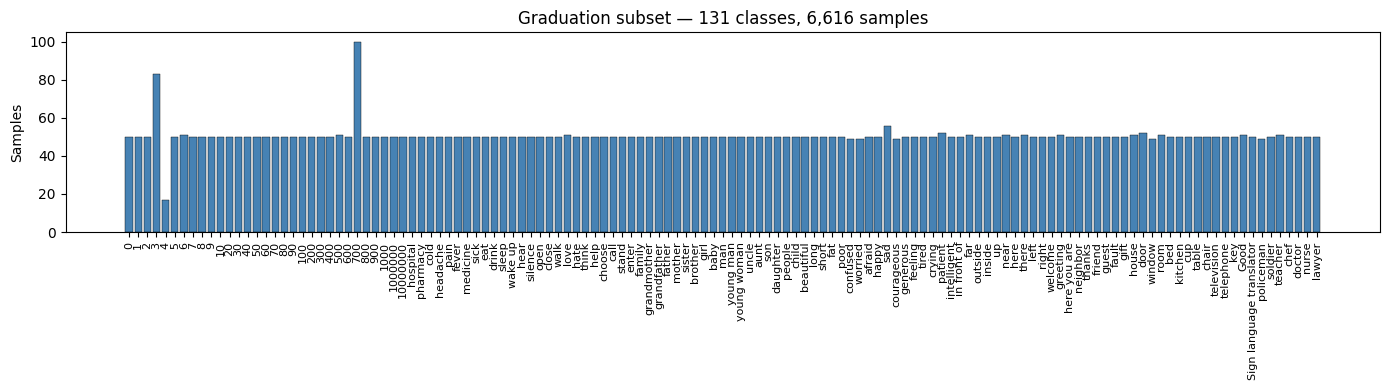

Min/max per class: 17 / 100


In [6]:
# Cell 6: Data exploration
unique_ids, counts = np.unique(y, return_counts=True)
names = [id_to_english.get(int(uid), str(uid)) for uid in unique_ids]

print(f'Vocabulary: {len(unique_ids)} trained / {GRADUATION_EXPECTED} target ({VOCAB_COVERAGE*100:.0f}% coverage)')
if GRADUATION_FOUND < GRADUATION_EXPECTED:
    print('⚠ PARTIAL RUN — finish NPZ extraction and re-run Cell 5 before thesis training')

fig, ax = plt.subplots(figsize=(14, 4))
ax.bar(names, counts, color='steelblue', edgecolor='black', linewidth=0.3)
ax.set_xticklabels(names, rotation=90, fontsize=8)
ax.set_title(f'Graduation subset — {len(unique_ids)} classes, {len(y):,} samples')
ax.set_ylabel('Samples')
plt.tight_layout()
plt.show()

print(f'Min/max per class: {counts.min()} / {counts.max()}')


In [7]:
# Cell 7: Preprocessing & splits  (split first → scaler fit on train only — no leakage)
print('Preprocessing ...')

encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)
num_classes = len(encoder.classes_)
y_onehot = to_categorical(y_encoded, num_classes=num_classes)

class_df = pd.DataFrame({
    'model_class_index': range(num_classes),
    'karsl_class_id': encoder.classes_.tolist(),
    'english': [id_to_english.get(int(c), str(c)) for c in encoder.classes_],
    'arabic': [id_to_arabic.get(int(c), str(c)) for c in encoder.classes_],
})
class_df.to_csv(OUTPUT_DIR / f'{OUTPUT_PREFIX}_classes.csv', index=False)
print(f'Class map saved ({num_classes} classes)')
print(class_df.head(10).to_string())

# Per-class split — block holdout (NPZ order) or shuffled stratified
def split_per_class(X_arr, y_arr, y_oh, holdout=0.35, seed=42, block_holdout=True):
    """Split each class into train/val/test.

    block_holdout=True: sequential blocks (matches extraction order in NPZ — less signer leakage).
    block_holdout=False: shuffle within class then split (legacy random stratified).
    """
    rng = np.random.default_rng(seed)
    val_ratio = holdout / 2
    test_ratio = holdout / 2
    tr_idx, va_idx, te_idx = [], [], []

    for cid in np.unique(y_arr):
        idx = np.where(y_arr == cid)[0]
        if not block_holdout:
            rng.shuffle(idx)
        n = len(idx)
        if n == 1:
            tr_idx.extend(idx.tolist())
            continue
        n_te = max(1, int(round(n * test_ratio)))
        n_va = max(1, int(round(n * val_ratio)))
        if n_te + n_va >= n:
            n_te = 1 if n >= 3 else 0
            n_va = 1 if n >= 2 else 0
        n_tr = n - n_va - n_te
        if n_tr < 1:
            n_tr = 1
            n_va = max(0, n_va - 1) if n_va > 0 else 0
            n_te = n - n_tr - n_va
        tr_idx.extend(idx[:n_tr].tolist())
        va_idx.extend(idx[n_tr:n_tr + n_va].tolist())
        te_idx.extend(idx[n_tr + n_va:].tolist())

    to = lambda ix: (X_arr[ix], y_oh[ix])
    return (*to(tr_idx), *to(va_idx), *to(te_idx))

split_mode = 'block holdout (NPZ order)' if BLOCK_HOLDOUT_SPLIT else 'shuffled per-class'
X_train, y_train, X_val, y_val, X_test, y_test = split_per_class(
    X, y, y_onehot, holdout=TEST_SIZE, seed=42, block_holdout=BLOCK_HOLDOUT_SPLIT
)
print(f'Split strategy: {split_mode} → ~{int((1-TEST_SIZE)*100)}% / {int(TEST_SIZE/2*100)}% / {int(TEST_SIZE/2*100)}%')
print(f'Train {X_train.shape[0]} | Val {X_val.shape[0]} | Test {X_test.shape[0]}')

# StandardScaler: fit on TRAIN only, transform all splits
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train.reshape(-1, NUM_FEATURES)).reshape(X_train.shape).astype(np.float32)
X_val   = scaler.transform(X_val.reshape(-1, NUM_FEATURES)).reshape(X_val.shape).astype(np.float32)
X_test  = scaler.transform(X_test.reshape(-1, NUM_FEATURES)).reshape(X_test.shape).astype(np.float32)

np.savez_compressed(
    str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_scaler.npz'),
    mean=scaler.mean_.astype(np.float32),
    scale=scaler.scale_.astype(np.float32),
)
print('Scaler fit on train split only ✔')

train_ints = np.argmax(y_train, axis=1)
cw_array = compute_class_weight('balanced', classes=np.arange(num_classes), y=train_ints)
cw_array = np.clip(cw_array, 0.5, 10.0)
class_weights = dict(enumerate(cw_array))

# Per-split class coverage check
for name, y_split in [('train', y_train), ('val', y_val), ('test', y_test)]:
    present = len(np.unique(np.argmax(y_split, axis=1)))
    print(f'  {name:5s}: {present}/{num_classes} classes represented')

test_cls = np.unique(np.argmax(y_test, axis=1))
if len(test_cls) < num_classes:
    missing_test = set(range(num_classes)) - set(test_cls)
    print(f'  ⚠ test split missing {len(missing_test)} class(es) — small classes may have too few samples')

if GRADUATION_FOUND < GRADUATION_EXPECTED and not ALLOW_PARTIAL_TRAINING:
    raise RuntimeError(
        f'Partial vocabulary ({GRADUATION_FOUND}/{GRADUATION_EXPECTED}). '
        'Re-run after full NPZ extraction, or set ALLOW_PARTIAL_TRAINING=True for smoke tests.'
    )


Preprocessing ...
Class map saved (131 classes)
   model_class_index  karsl_class_id english arabic
0                  0               2       0      0
1                  1               3       1      1
2                  2               4       2      2
3                  3               5       3      3
4                  4               6       4      4
5                  5               7       5      5
6                  6               8       6      6
7                  7               9       7      7
8                  8              10       8      8
9                  9              11       9      9
Split strategy: block holdout (NPZ order) → ~65% / 17% / 17%
Train 4238 | Val 1189 | Test 1189
Scaler fit on train split only ✔
  train: 131/131 classes represented
  val  : 131/131 classes represented
  test : 131/131 classes represented


In [8]:
# Cell 8: Build & train  ── BiLSTM + MultiHeadAttention model
if not ALLOW_PARTIAL_TRAINING and GRADUATION_FOUND < GRADUATION_EXPECTED:
    raise RuntimeError(
        f'Partial vocabulary ({GRADUATION_FOUND}/{GRADUATION_EXPECTED} classes). '
        'Finish NPZ extraction and re-run Cell 5, or set ALLOW_PARTIAL_TRAINING = True for smoke tests.'
    )

random_baseline_top1 = 100.0 / num_classes
print('=' * 60)
print(f'TRAINING — {num_classes} output classes  ({GRADUATION_FOUND}/{GRADUATION_EXPECTED} graduation vocab)')
if GRADUATION_FOUND < GRADUATION_EXPECTED:
    print('⚠ PARTIAL VOCABULARY — do not use these metrics in the thesis')
print(f'Random baseline: top-1 {random_baseline_top1:.2f}% | top-5 {min(100.0, random_baseline_top1 * 5):.2f}%')
print('=' * 60)

tf.keras.backend.clear_session()

POSE_F = tf.constant(POSE_FEATURES, dtype=tf.int32)
HAND_F = tf.constant(HAND_FEATURES, dtype=tf.int32)

# ── Augmentation (matches ArSL_Word_Training_v2.ipynb — no tf.image.resize) ──
def augment_sequence(x, y_label):
    # Gaussian noise
    x = x + tf.random.normal(tf.shape(x), mean=0.0, stddev=0.007)
    # Temporal shift ±4 frames
    x = tf.roll(x, shift=tf.random.uniform([], -4, 5, dtype=tf.int32), axis=0)
    # Random frame dropout 12 %
    mask = tf.cast(tf.random.uniform([SEQUENCE_LENGTH, 1]) > 0.12, tf.float32)
    x = x * mask
    # Random scale (signer distance variation)
    x = x * tf.random.uniform([], 0.9, 1.1)
    # Random horizontal flip (swap left ↔ right hand)
    def flip_hands():
        pose = x[:, :POSE_F]
        lh   = x[:, POSE_F:POSE_F + HAND_F]
        rh   = x[:, POSE_F + HAND_F:]
        return tf.concat([pose, rh, lh], axis=-1)
    x = tf.cond(tf.random.uniform([]) > 0.5, flip_hands, lambda: x)
    return x, y_label

def augment_sequences(X_input, y_input, factor=3, seed=42):
    """Augment training sequences with time jitter, spatial noise, time scale."""
    rng = np.random.default_rng(seed)
    aug_X, aug_y = [X_input], [y_input]

    for _ in range(factor - 1):
        batch = X_input.copy()

        # Time jitter: random roll ±3 frames
        shifts = rng.integers(-3, 4, size=len(batch))
        for i, s in enumerate(shifts):
            batch[i] = np.roll(batch[i], s, axis=0)

        # Spatial noise: σ=0.005
        batch = batch + rng.normal(0, 0.005, batch.shape).astype(np.float32)

        # Time scale: randomly stretch or compress by 0.85–1.15×
        scale = rng.uniform(0.85, 1.15)
        orig_len = batch.shape[1]
        new_len = max(1, int(orig_len * scale))
        idx = np.linspace(0, orig_len - 1, new_len).astype(int)
        scaled = batch[:, idx, :]
        idx2 = np.linspace(0, new_len - 1, orig_len).astype(int)
        batch = scaled[:, idx2, :]

        aug_X.append(batch)
        aug_y.append(y_input)

    X_out = np.concatenate(aug_X, axis=0).astype(np.float32)
    y_out = np.concatenate(aug_y, axis=0)
    perm = rng.permutation(len(X_out))
    return X_out[perm], y_out[perm]

if AUGMENT_TRAIN:
    print(f'Applying offline augmentation (factor=3) ...')
    X_train_final, y_train_final = augment_sequences(X_train, y_train, factor=3)
    print(f'  Augmented train size: {len(X_train_final):,} (was {len(X_train):,})')
else:
    X_train_final, y_train_final = X_train, y_train

AUTOTUNE = tf.data.AUTOTUNE
train_ds = (
    tf.data.Dataset.from_tensor_slices((X_train_final, y_train_final))
    .shuffle(min(len(X_train_final), 24000), seed=42)
    .map(augment_sequence, num_parallel_calls=AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(AUTOTUNE)
)
val_ds  = tf.data.Dataset.from_tensor_slices((X_val,  y_val )).batch(BATCH_SIZE).prefetch(AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(BATCH_SIZE).prefetch(AUTOTUNE)

# ── Architecture: TD spatial encoder → BiLSTM stack → MHA → dense head ─────
inputs = Input(shape=(SEQUENCE_LENGTH, NUM_FEATURES), name='landmark_input')

x = TimeDistributed(Dense(SPATIAL_ENC_1, activation='relu'), name='td_enc_1')(inputs)
x = TimeDistributed(BatchNormalization(), name='td_bn_1')(x)
x = TimeDistributed(Dropout(0.2), name='td_drop_1')(x)
x = TimeDistributed(Dense(SPATIAL_ENC_2, activation='relu'), name='td_enc_2')(x)
x = TimeDistributed(BatchNormalization(), name='td_bn_2')(x)

x = Bidirectional(LSTM(LSTM_UNITS_1, return_sequences=True), name='bilstm_1')(x)
x = BatchNormalization(name='bn_1')(x)
x = tf.keras.layers.SpatialDropout1D(DROPOUT_RATE, name='sdrop_1')(x)
x = Bidirectional(LSTM(LSTM_UNITS_2, return_sequences=True), name='bilstm_2')(x)
x = BatchNormalization(name='bn_2')(x)
x = tf.keras.layers.SpatialDropout1D(DROPOUT_RATE, name='sdrop_2')(x)

# MultiHead self-attention — critical for 100 semantically-close signs
attn_out, _ = tf.keras.layers.MultiHeadAttention(
    num_heads=4, key_dim=LSTM_UNITS_2 // 4, dropout=0.1, name='mha'
)(x, x, return_attention_scores=True)
x = tf.keras.layers.Add(name='residual_add')([x, attn_out])
x = tf.keras.layers.LayerNormalization(name='layer_norm')(x)

x = LSTM(LSTM_UNITS_3, return_sequences=False, name='lstm_final')(x)
x = BatchNormalization(name='bn_lstm_final')(x)
x = Dropout(DROPOUT_RATE, name='drop_lstm')(x)

x = Dense(DENSE_UNITS, activation='relu', name='dense_1')(x)
x = BatchNormalization(name='bn_dense_1')(x)
x = Dropout(DROPOUT_RATE, name='drop_1')(x)
x = Dense(DENSE_UNITS // 2, activation='relu', name='dense_2')(x)
x = Dropout(DROPOUT_RATE * 0.5, name='drop_2')(x)
outputs = Dense(num_classes, activation='softmax', dtype='float32', name='output')(x)

model = Model(inputs, outputs, name='ArSL_100Words_GradProject')

# Fixed LR + ReduceLROnPlateau (CosineDecay breaks Keras 2.10 progress bar)
optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE, clipnorm=GRAD_CLIP_NORM)
loss_fn   = tf.keras.losses.CategoricalCrossentropy(label_smoothing=LABEL_SMOOTH)
model.compile(
    optimizer=optimizer,
    loss=loss_fn,
    metrics=['accuracy', tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc')],
)
model.summary()

MODEL_BEST  = str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_best.h5')
MODEL_FINAL = str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_final.h5')
callbacks = [
    ModelCheckpoint(MODEL_BEST, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=EARLY_STOP_PATIENCE, restore_best_weights=True, verbose=1),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=10, min_lr=1e-6, verbose=1
    ),
    tf.keras.callbacks.TerminateOnNaN(),
]

print(f'Training on {DEVICE} ...')
print(f'  Architecture : TD {SPATIAL_ENC_1}→{SPATIAL_ENC_2} | BiLSTM {LSTM_UNITS_1}→{LSTM_UNITS_2} | MHA(4h) | LSTM {LSTM_UNITS_3} | Dense {DENSE_UNITS}→{DENSE_UNITS//2} → {num_classes}')
t0 = time.time()
with tf.device(DEVICE):
    history = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=EPOCHS,
        callbacks=callbacks,
        class_weight=class_weights,
        verbose=1,
    )
print(f'Done in {(time.time()-t0)/60:.1f} min | best val_acc {max(history.history["val_accuracy"]):.4f}')
model.save(MODEL_FINAL)
print(f'Saved: {MODEL_BEST}')


TRAINING — 131 output classes  (131/131 graduation vocab)
Random baseline: top-1 0.76% | top-5 3.82%
Applying offline augmentation (factor=3) ...
  Augmented train size: 12,714 (was 4,238)
Model: "ArSL_100Words_GradProject"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 landmark_input (InputLayer)    [(None, 48, 258)]    0           []                               
                                                                                                  
 td_enc_1 (TimeDistributed)     (None, 48, 256)      66304       ['landmark_input[0][0]']         
                                                                                                  
 td_bn_1 (TimeDistributed)      (None, 48, 256)      1024        ['td_enc_1[0][0]']               
                                                                                   

 EVALUATION SUMMARY
Vocabulary   : 131 trained / 131 graduation target
Random baseline top-1 : 0.76%
Best val accuracy     : 95.46%  (model selection only — not thesis metric)
Test Top-1 accuracy   : 96.64%  ← report this
Test Top-5 accuracy   : 98.40%
Test Macro-F1         : 96.66%
Test Weighted-F1      : 96.60%
Test samples          : 1189
Metrics saved: arsl_custom_eval_metrics.csv

Classification report (test set):
                          precision    recall  f1-score   support

                       0       0.71      0.56      0.62         9
                       1       1.00      0.78      0.88         9
                       2       1.00      0.56      0.71         9
                       3       1.00      0.93      0.97        15
                       4       0.50      0.67      0.57         3
                       5       1.00      0.67      0.80         9
                       6       0.60      1.00      0.75         9
                       7       0.86      0.67   

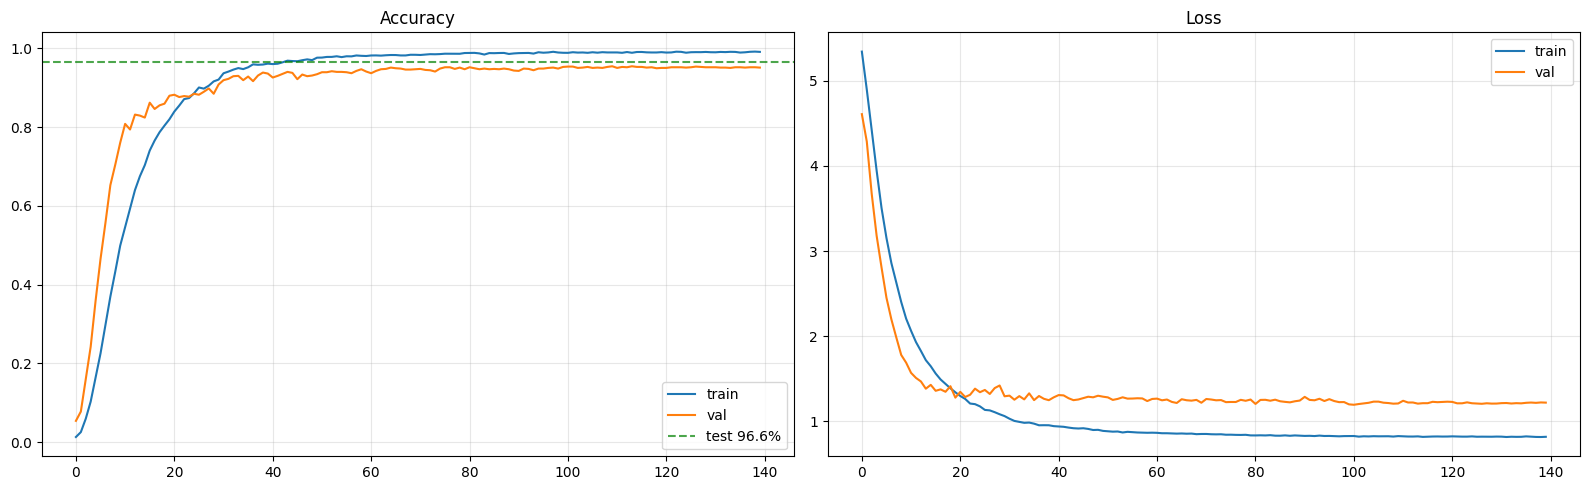

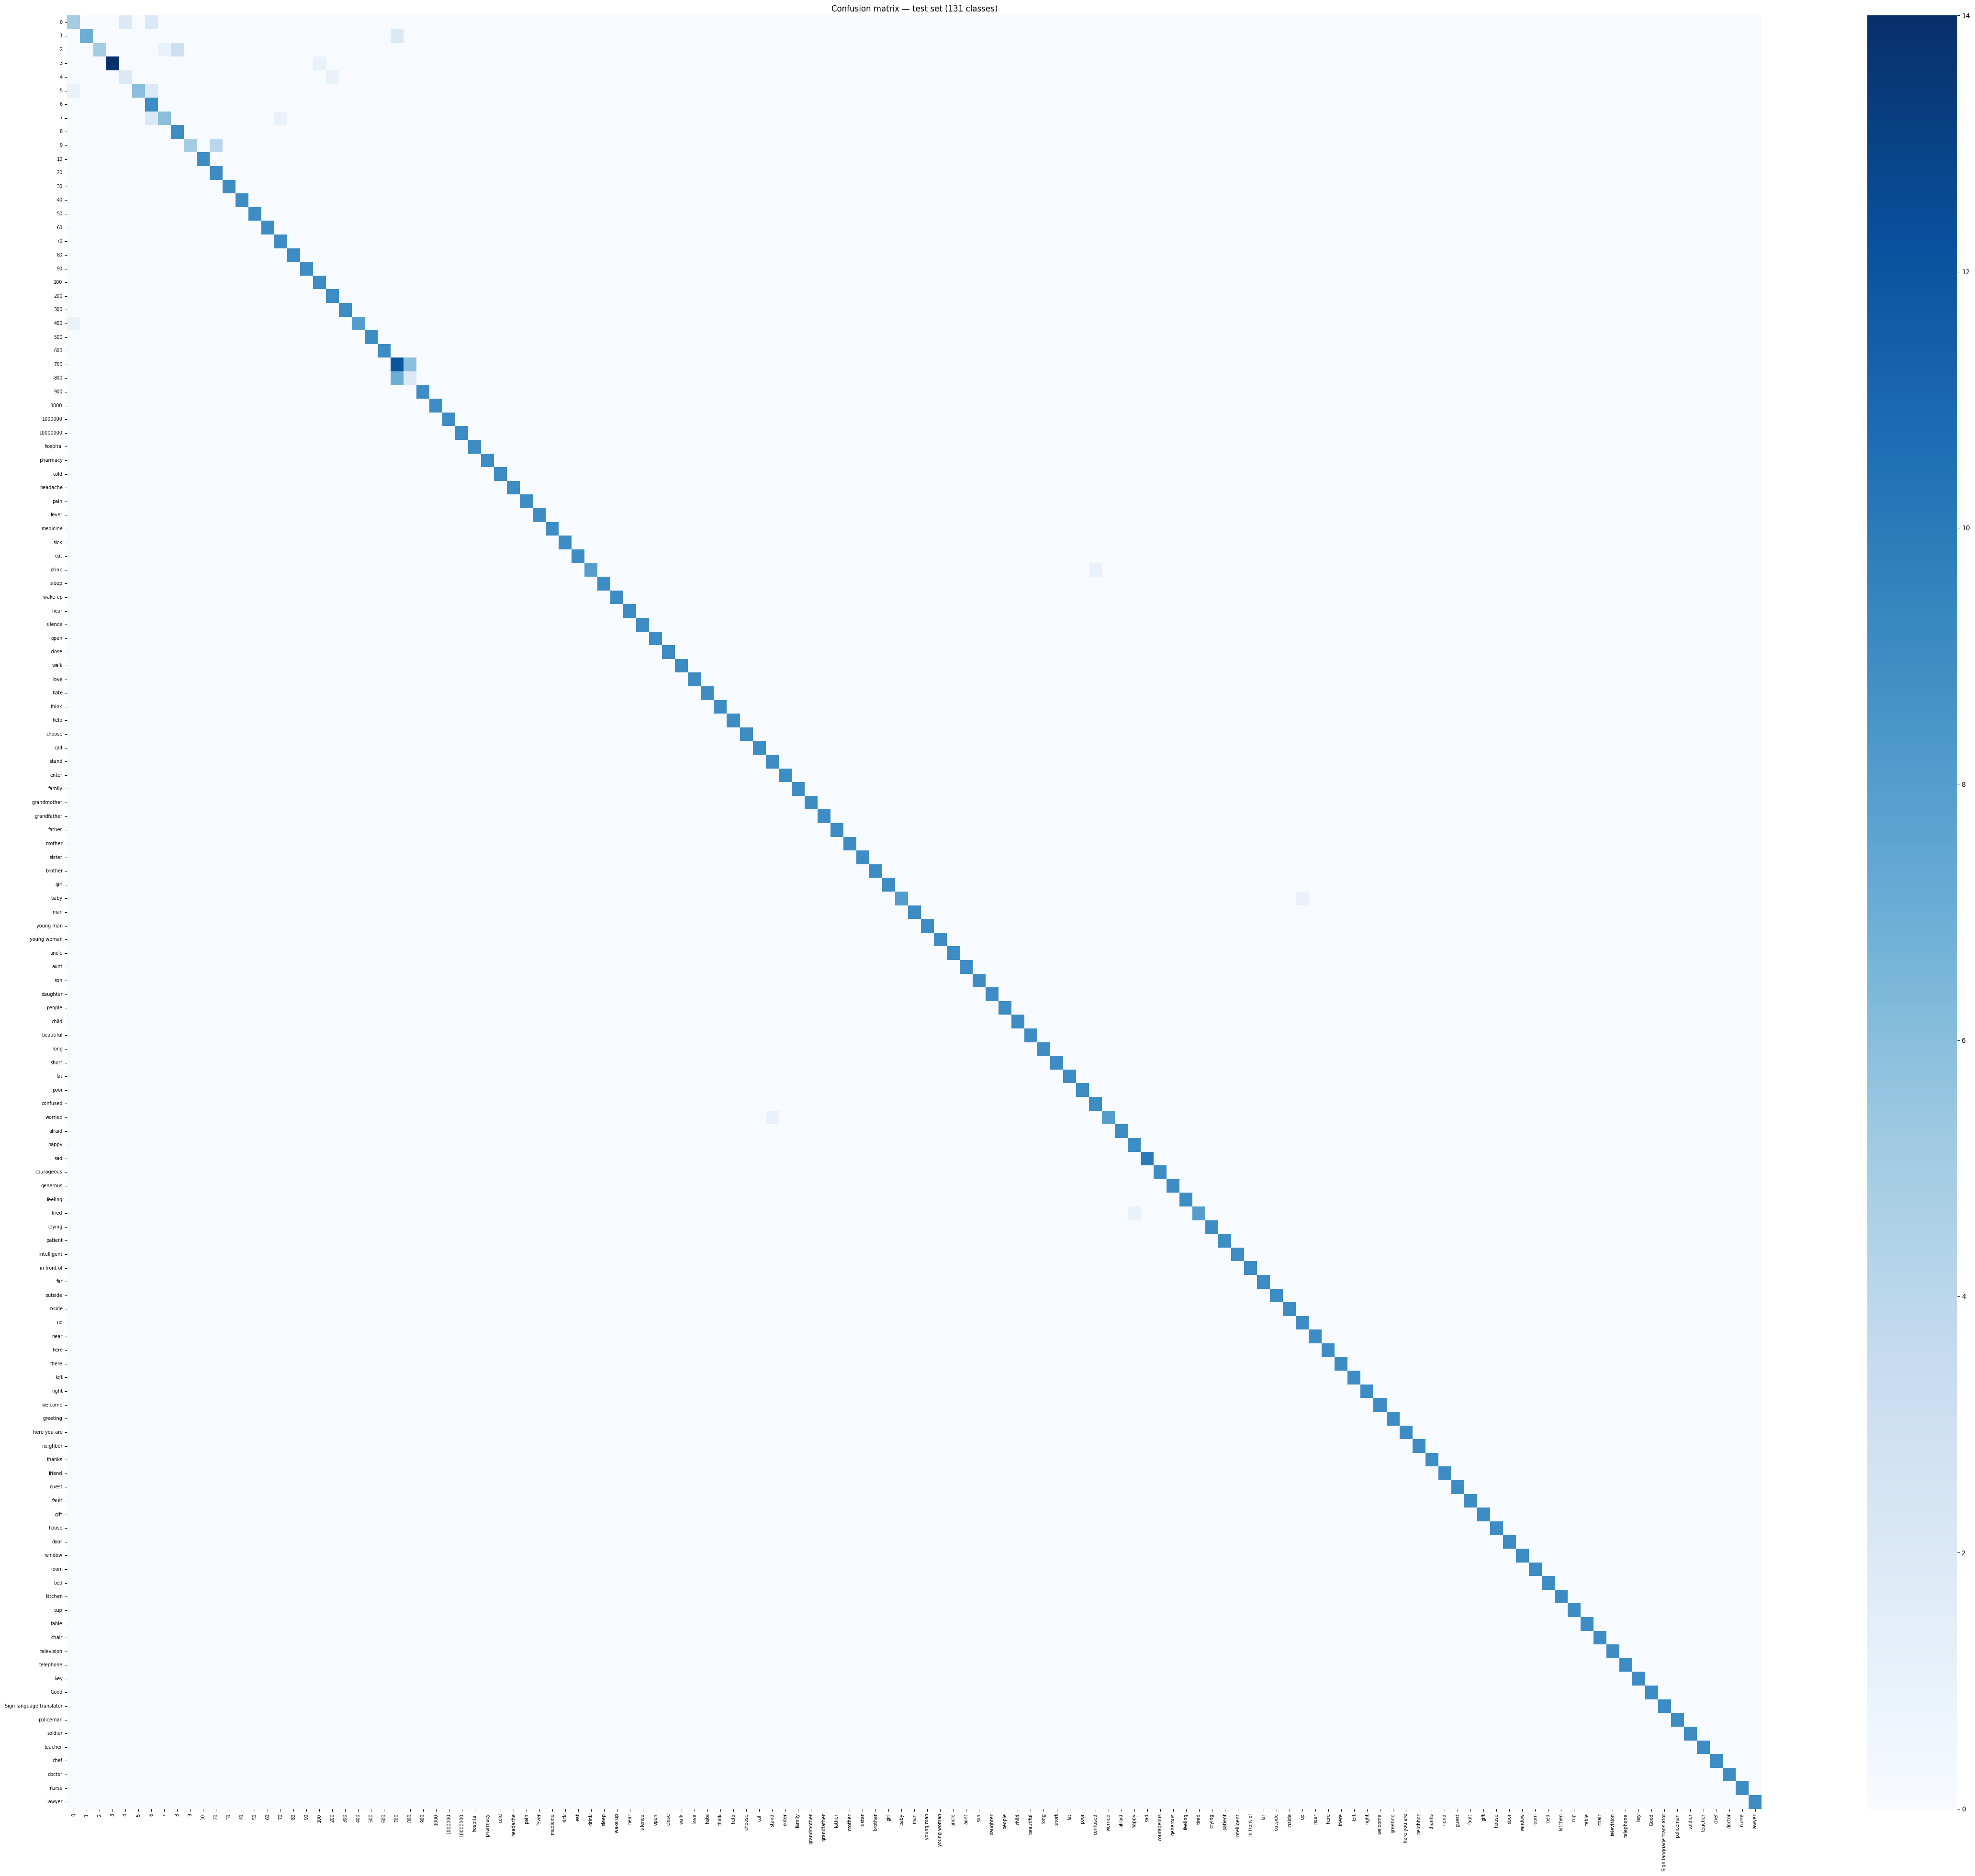

In [9]:
# Cell 9: Evaluation  (held-out TEST set — report these numbers in thesis)
# NOTE: Safe to run even if training was interrupted or Cell 8 was skipped.
from sklearn.metrics import f1_score, accuracy_score

# Define paths in case Cell 8 was skipped
try:
    MODEL_BEST
except NameError:
    MODEL_BEST  = str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_best.h5')
    MODEL_FINAL = str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_final.h5')

# Rebuild test_ds if Cell 8 was skipped (X_test, y_test come from the preprocessing cell)
try:
    test_ds
except NameError:
    _AUTOTUNE = tf.data.AUTOTUNE
    test_ds = (
        tf.data.Dataset.from_tensor_slices((X_test, y_test))
        .batch(BATCH_SIZE)
        .prefetch(_AUTOTUNE)
    )
    print('ℹ test_ds rebuilt from X_test / y_test (Cell 8 was skipped)')

best_model = tf.keras.models.load_model(MODEL_BEST)
with tf.device(DEVICE):
    proba = best_model.predict(test_ds, verbose=0)

y_pred = np.argmax(proba, axis=1)
y_true = np.argmax(y_test, axis=1)
top1 = accuracy_score(y_true, y_pred)
top5 = sum(1 for i in range(len(y_true)) if y_true[i] in np.argsort(proba[i])[-5:]) / len(y_true)
macro_f1 = f1_score(y_true, y_pred, average='macro', zero_division=0)
weighted_f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

# history may not exist if training was interrupted — handle gracefully
try:
    best_val = max(history.history['val_accuracy'])
    _has_history = True
except NameError:
    best_val = None
    _has_history = False
    print('ℹ Training history not in memory (interrupted or restarted). Loaded best checkpoint from disk.')

try:
    word_labels
except NameError:
    word_labels = [id_to_english.get(int(encoder.classes_[i]), str(encoder.classes_[i])) for i in range(num_classes)]

print('=' * 60)
print(' EVALUATION SUMMARY')
print('=' * 60)
print(f'Vocabulary   : {num_classes} trained / {GRADUATION_EXPECTED} graduation target')
if GRADUATION_FOUND < GRADUATION_EXPECTED:
    print('⚠ PARTIAL RUN — not valid for 131-class thesis claims')
print(f'Random baseline top-1 : {100/num_classes:.2f}%')
if best_val is not None:
    print(f'Best val accuracy     : {best_val*100:.2f}%  (model selection only — not thesis metric)')
print(f'Test Top-1 accuracy   : {top1*100:.2f}%  ← report this')
print(f'Test Top-5 accuracy   : {top5*100:.2f}%')
print(f'Test Macro-F1         : {macro_f1*100:.2f}%')
print(f'Test Weighted-F1      : {weighted_f1*100:.2f}%')
print(f'Test samples          : {len(y_true)}')
print('=' * 60)

import datetime
metrics_df = pd.DataFrame([{
    'timestamp': datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S'),
    'test_top1_accuracy': round(top1, 4),
    'macro_f1': round(macro_f1, 4),
    'num_classes': num_classes,
    'num_test_samples': len(y_true),
    'test_top5_accuracy': round(top5, 4),
    'test_weighted_f1': round(weighted_f1, 4),
    'best_val_accuracy': round(best_val, 4) if best_val is not None else None,
    'graduation_expected': GRADUATION_EXPECTED,
    'graduation_found': GRADUATION_FOUND,
    'split_strategy': 'block_holdout' if BLOCK_HOLDOUT_SPLIT else 'shuffled',
}])
metrics_path = OUTPUT_DIR / f'{OUTPUT_PREFIX}_eval_metrics.csv'
if metrics_path.exists():
    metrics_df.to_csv(metrics_path, mode='a', header=False, index=False)
else:
    metrics_df.to_csv(metrics_path, index=False)
print(f'Metrics saved: {metrics_path.name}')

print('\nClassification report (test set):')
print(classification_report(y_true, y_pred, target_names=word_labels, zero_division=0))

# Per-class accuracy table sorted ascending (to find weak classes)
class_correct = np.zeros(num_classes, dtype=int)
class_total = np.zeros(num_classes, dtype=int)
for t, p in zip(y_true, y_pred):
    class_total[t] += 1
    if t == p:
        class_correct[t] += 1

per_class_df = pd.DataFrame({
    'english': word_labels,
    'correct': class_correct,
    'total': class_total,
    'accuracy': np.where(class_total > 0, class_correct / class_total, 0.0),
})
per_class_df = per_class_df[per_class_df['total'] > 0].sort_values('accuracy')
print('\nPer-class accuracy (sorted ascending — weakest first):')
print(per_class_df[['english', 'correct', 'total', 'accuracy']].to_string(index=False))

# Category-level accuracy summary
if 'category' in words_df.columns:
    cat_map = {
        row['english']: row.get('category', 'unknown')
        for _, row in words_df[['english', 'category']].drop_duplicates('english').iterrows()
    }
    per_class_df['category'] = per_class_df['english'].map(cat_map).fillna('unknown')
    cat_acc = per_class_df.groupby('category').apply(
        lambda g: pd.Series({
            'correct': int(g['correct'].sum()),
            'total': int(g['total'].sum()),
            'accuracy': g['correct'].sum() / max(g['total'].sum(), 1),
        })
    ).reset_index().sort_values('accuracy')
    print('\nCategory-level accuracy:')
    print(cat_acc[['category', 'correct', 'total', 'accuracy']].to_string(index=False))

if _has_history:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    axes[0].plot(history.history['accuracy'], label='train')
    axes[0].plot(history.history['val_accuracy'], label='val')
    axes[0].axhline(top1, color='green', ls='--', alpha=0.7, label=f'test {top1*100:.1f}%')
    axes[0].set_title('Accuracy'); axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(history.history['loss'], label='train')
    axes[1].plot(history.history['val_loss'], label='val')
    axes[1].set_title('Loss'); axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_training_curves.png'), dpi=150)
    plt.show()
else:
    print('ℹ Training curves not available (history lost after interruption).')

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(max(8, num_classes * 0.35), max(6, num_classes * 0.3)))
sns.heatmap(cm, xticklabels=word_labels, yticklabels=word_labels, cmap='Blues', fmt='d')
plt.title(f'Confusion matrix — test set ({num_classes} classes)')
plt.xticks(rotation=90, fontsize=7)
plt.yticks(rotation=0, fontsize=7)
plt.tight_layout()
plt.savefig(str(OUTPUT_DIR / f'{OUTPUT_PREFIX}_confusion_matrix.png'), dpi=150)
plt.show()


### Troubleshooting

| Issue | Fix |
|-------|-----|
| Full NPZ missing | Finish `ArSL_Word_Training_v2.ipynb` Cell 6 first |
| `Incomplete vocabulary` (Cell 5) | Extraction still running — re-run Cell 5 after full NPZ; or set `REQUIRE_FULL_VOCABULARY = False` for smoke tests only |
| `Partial vocabulary` (Cell 8) | Set `ALLOW_PARTIAL_TRAINING = True` for debugging only — thesis runs need full 131 classes |
| Scaler leakage | Fixed: Cell 7 fits scaler on **train split only** |
| Inflated accuracy (signer leakage) | Default `BLOCK_HOLDOUT_SPLIT=True` — sequential per-class blocks from NPZ order |
| `expected (None, 48, 258), found (None, 258, 258)` | Bad augmentation shape — fixed in Cell 8; re-run from Cell 8 |
| Change vocabulary | Edit `KARSL-502_GraduationSelection.csv`, re-run from Cell 5 |
| sign_id not in master | Use SignID from `KARSL-502_Labels.txt` (1–502); class_id = sign_id + 1 |
| OOM on MX150 | Set `BATCH_SIZE = 16` in Cell 3, or train on Kaggle T4 |
| Thesis metrics | Use **Cell 9 test** top-1 / macro-F1 — not val accuracy |
